# EndoScan — MRI Scan Explainer
## CRISP-DM Data Science Lifecycle

---
**Project:** EndoScan MRI Explanation Path (complementary tool)
**Model:** EfficientNet-B0 Binary Classifier → finding + confidence → Grad-CAM → plain-language explanation
**Methodology:** CRISP-DM (6 phases)
**Data:** Real extracted slices (`outputs/mri_slices`) + synthetic augmented slices
(`outputs/augmented/mri`), both keyed by `patient_id`

---
### Architecture Context
```
DIAGNOSTIC PATHS (do the severity scoring / tiering)
  NLP Path (live)          → free-text symptoms   → ESI score + tier ─┐
  Structured Path (live)   → questionnaire answers → ESI score + tier ─┴─► Fusion Layer → Unified ESI

COMPLEMENTARY EXPLAINER PATHS (this notebook is one of these — does NOT diagnose or tier)
  Laparoscopy / MRI / Ultrasound → scan image → finding + confidence + Grad-CAM ─► GenAI → plain-language explanation
  Only offered to patients who are ALREADY diagnosed and want their existing
  scan explained in plain language — not part of the ESI scoring pipeline at all.
```
**This is the important correction from the earlier version of this notebook:**
the MRI path does not output an `esi_score` or `esi_tier`, and it is not an
input to the fusion layer. Only the structured-questionnaire and NLP paths do
diagnostic severity scoring. This notebook's job stops at: classify the scan,
show where the model looked (Grad-CAM), report a calibrated confidence, and
hand that off to a GenAI layer that explains it to the patient in plain
language — mirroring what the laparoscopy notebook already does with its
Gemini explanation cells.

---
## Phase 1 — Business Understanding
Define the objective, the primary evaluation metric, and success criteria before touching data.

In [33]:
# Phase 1 — Business Understanding
# No computation here — documented as the project contract

BUSINESS_OBJECTIVE = """
The MRI path is a COMPLEMENTARY EXPLAINER, not a diagnostic tool. It is only
offered to patients who have already been diagnosed (via the structured/NLP
severity-scoring path or by a clinician) and who feel their MRI scan wasn't
fully explained to them.

Given a T2-weighted pelvic MRI slice, this path outputs:
  - a finding classification (endo indicators present / not present)
  - a calibrated confidence score
  - a Grad-CAM attention map showing where the model looked
These feed a GenAI layer (see the laparoscopy notebook's Gemini cells for the
pattern) that turns them into a warm, plain-language explanation for the
patient — never a diagnosis, never a severity tier, and never an input to the
fusion layer that produces the unified ESI score.

Primary clinical concern: an explanation that confidently describes a finding
which isn't really there (or misses one that is) actively misleads a patient
about their own diagnosed condition. Missing a true positive (false negative)
is the worse failure mode of the two, so RECALL (sensitivity) is still the
primary metric for the underlying classifier — not AUC, not accuracy — even
though this path's output is an explanation rather than a score.
"""

# Recall is PRIMARY. Everything else is diagnostic/secondary.
SUCCESS_CRITERIA = {
    'Recall':      0.80,   # PRIMARY — minimum acceptable sensitivity
    'Specificity': 0.75,   # secondary — floor, not the optimisation target
    'AUC':         0.85,   # secondary — diagnostic only
}

print("Phase 1 — Business Understanding")
print("=" * 50)
print("Role             : Complementary explainer (NOT diagnostic, NOT in fusion layer)")
print("Audience         : Already-diagnosed patients wanting their scan explained")
print("Primary metric   : Recall (sensitivity)")
print("Secondary floor  : Specificity >= 0.75")
print("Diagnostic only  : AUC")
print(f"\nSuccess criteria  : Recall ≥ {SUCCESS_CRITERIA['Recall']}  |  "
      f"Specificity ≥ {SUCCESS_CRITERIA['Specificity']}  |  "
      f"AUC ≥ {SUCCESS_CRITERIA['AUC']} (informational)")

Phase 1 — Business Understanding
Role             : Complementary explainer (NOT diagnostic, NOT in fusion layer)
Audience         : Already-diagnosed patients wanting their scan explained
Primary metric   : Recall (sensitivity)
Secondary floor  : Specificity >= 0.75
Diagnostic only  : AUC

Success criteria  : Recall ≥ 0.8  |  Specificity ≥ 0.75  |  AUC ≥ 0.85 (informational)


**What this cell does:** Declares the project's business objective and — critically — states that this path is a **complementary explainer, not a diagnostic tool**: it's only offered to patients who are already diagnosed (via the structured/NLP severity-scoring path or a clinician) and want their MRI explained in plain language. It does not output a severity score or tier, and its output never reaches the fusion layer — only the structured and NLP paths do that. The success criteria table still puts **recall as the primary metric** for the underlying classifier, since a misleading explanation of an already-diagnosed patient's scan is a real harm even though this path doesn't diagnose. Nothing here touches data; it's the written contract the rest of the notebook is held to.

---
## Phase 2 — Data Understanding
Structural audit of both the real and synthetic slice sets, and EDA before any modelling decision is made.

In [34]:
# ── Imports & config ──────────────────────────────────────────────
import json, copy, time, random, re
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy.ndimage import rotate, zoom as scipy_zoom

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import timm

PALETTE = {'Low': '#4CAF50', 'Moderate': '#FF9800', 'High': '#F44336', 'Critical': '#9C27B0'}
ACCENT = '#7C83FD'

# ── Paths — update to match your actual folders ───────────────────
# Pointed at v2: mask-derived slice labels (resampled em masks), not the
# original whole-patient labels. See mri_mask_relabel.ipynb for how these
# were generated and why (fixes label noise + a mask/T2 shape-mismatch bug
# that was silently discarding ~half the em segmentations).
REAL_PNG_DIR   = Path('./outputs/mri_slices_v2')
REAL_RECORDS   = Path('./outputs/mri_slice_records_v2.json')
# ⚠ AUG_PNG_DIR must be regenerated against the v2 labels before use — the
# existing augmented set was built from the OLD labels, and ~230 slices
# changed label between v1 and v2. Do not point this at the old augmented
# folder until it's been rebuilt from v2 positive slices.
AUG_PNG_DIR    = Path('./outputs/augmented/mri_v2')
CHECKPOINT_PATH = Path('./outputs/mri_best_model.pt')
RESULTS_DIR    = Path('./outputs')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 224
BATCH_SIZE    = 32
EPOCHS        = 50
LR            = 1e-4
WEIGHT_DECAY  = 1e-4
PATIENCE      = 8
FREEZE_BLOCKS = 6
DROPOUT       = 0.3
SEED          = 42
NUM_WORKERS   = 0

# Whether synthetic slices are added only for the minority (positive) class,
# or for both classes. Default True — the imbalance problem is on the
# positive side (real data is roughly 1:11 positive:negative at the slice
# level), so that's where augmentation should help most.
AUGMENT_POSITIVE_ONLY = True

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device : {DEVICE}")
print(f"Real PNG dir      : {REAL_PNG_DIR}")
print(f"Augmented PNG dir : {AUG_PNG_DIR}")
print(f"Augment scope     : {'positive class only' if AUGMENT_POSITIVE_ONLY else 'both classes'}")

# ── Load real records from JSON (carries institution — don't discard it) ──
# Schema per record: patient_id, institution, slice_idx, label, t2_path, is_d1
with open(REAL_RECORDS) as f:
    real_records = json.load(f)

for r in real_records:
    r['source'] = 'real'
    r['dir'] = REAL_PNG_DIR
    r['filename'] = f"{r['patient_id']}_sl{r['slice_idx']:03d}_label{r['label']}.png"

print(f"Real records loaded from JSON : {len(real_records):,}")

# is_d1 is just institution re-encoded as boolean — confirm that assumption
# rather than trust it silently, since a mismatch would mean it's marking
# something else (e.g. an external validation cohort) that the split should
# respect.
institution_to_isd1 = {}
mismatch = False
for r in real_records:
    prev = institution_to_isd1.setdefault(r['institution'], r['is_d1'])
    if prev != r['is_d1']:
        mismatch = True
if mismatch:
    print("⚠ is_d1 does NOT map 1:1 with institution — it's marking something else.")
    print("  Do not proceed with institution-only stratification until this is understood.")
else:
    print(f"✓ is_d1 confirmed redundant with institution: {institution_to_isd1}")

# Spot-check that PNGs referenced by the JSON actually exist on disk
missing = 0
for rec in random.sample(real_records, min(200, len(real_records))):
    if not (REAL_PNG_DIR / rec['filename']).exists():
        missing += 1
print(f"PNG spot-check: {'✓ all sampled files found' if missing==0 else f'⚠ {missing} missing'}")

# ── Build synthetic records from filenames (no JSON provided for these) ──
# Filename convention observed: {patient_id}_sl{slice_idx:03d}_label{label}_aug{N}.png
# (the _aug{N} suffix marks which augmented copy this is — real slices have no suffix)
FNAME_RE = re.compile(
    r'^(?P<patient_id>.+)_sl(?P<slice_idx>\d+)_label(?P<label>[01])(?:_aug(?P<aug_id>\d+))?\.png$'
)

def build_records_from_dir(png_dir: Path, source: str) -> list[dict]:
    records = []
    skipped = 0
    for p in sorted(png_dir.glob('*.png')):
        m = FNAME_RE.match(p.name)
        if not m:
            skipped += 1
            continue
        records.append({
            'patient_id': m.group('patient_id'),
            'slice_idx':  int(m.group('slice_idx')),
            'label':      int(m.group('label')),
            'aug_id':     m.group('aug_id'),   # None for real, str for synthetic
            'source':     source,
            'dir':        png_dir,
            'filename':   p.name,   # exact filename on disk — never reconstructed
        })
    if skipped:
        print(f"  ⚠ {skipped} files in {png_dir} did not match the naming convention — skipped")
    return records

aug_records = build_records_from_dir(AUG_PNG_DIR, source='synthetic')

# Attach institution to synthetic records via their source patient (real data)
patient_to_institution = {r['patient_id']: r['institution'] for r in real_records}
for r in aug_records:
    r['institution'] = patient_to_institution.get(r['patient_id'], 'unknown')

print(f"\nReal records      : {len(real_records):,}")
print(f"Synthetic records : {len(aug_records):,}")

# ── Sanity check: every synthetic patient_id must exist in real data ─
real_patient_ids = set(r['patient_id'] for r in real_records)
aug_patient_ids  = set(r['patient_id'] for r in aug_records)
orphan_synth_ids = aug_patient_ids - real_patient_ids

print(f"\nSynthetic patients            : {len(aug_patient_ids)}")
print(f"Synthetic patients NOT in real: {len(orphan_synth_ids)}")
assert not orphan_synth_ids, (
    f"{len(orphan_synth_ids)} synthetic patient_ids have no matching real "
    f"patient — cannot assign them to a split safely. Example: "
    f"{list(orphan_synth_ids)[:5]}"
)
print("✓ Every synthetic patient_id maps to a real patient — safe to attach to splits later")

# ── Class balance — real data only (this is the number that matters for EDA) ─
n_total = len(real_records)
n_pos   = sum(r['label'] == 1 for r in real_records)
n_neg   = n_total - n_pos
n_pts   = len(real_patient_ids)
pos_pts = len(set(r['patient_id'] for r in real_records if r['label'] == 1))
neg_pts = n_pts - pos_pts

print(f"\nREAL DATA — slice level")
print(f"  Total slices : {n_total:,}")
print(f"  Positive     : {n_pos:,}  ({n_pos/n_total*100:.1f}%)")
print(f"  Negative     : {n_neg:,}  ({n_neg/n_total*100:.1f}%)")
print(f"  Imbalance    : 1 : {n_neg // max(n_pos, 1)}")
print(f"\nREAL DATA — patient level (this is what actually drives split reliability)")
print(f"  Total patients    : {n_pts}")
print(f"  Positive patients : {pos_pts}")
print(f"  Negative patients : {neg_pts}")
if pos_pts < 15:
    print(f"  ⚠ Only {pos_pts} positive patients — a single train/val/test split will")
    print(f"    give a noisy recall estimate. Consider patient-level k-fold for the")
    print(f"    final reported number (see note in Phase 4).")

Device : cpu
Real PNG dir      : outputs/mri_slices_v2
Augmented PNG dir : outputs/augmented/mri_v2
Augment scope     : positive class only
Real records loaded from JSON : 4,242
✓ is_d1 confirmed redundant with institution: {'D1_MHS': True, 'D2_TCPW': False}
PNG spot-check: ✓ all sampled files found

Real records      : 4,242
Synthetic records : 0

Synthetic patients            : 0
Synthetic patients NOT in real: 0
✓ Every synthetic patient_id maps to a real patient — safe to attach to splits later

REAL DATA — slice level
  Total slices : 4,242
  Positive     : 356  (8.4%)
  Negative     : 3,886  (91.6%)
  Imbalance    : 1 : 10

REAL DATA — patient level (this is what actually drives split reliability)
  Total patients    : 92
  Positive patients : 44
  Negative patients : 48


**What this cell does:** Sets up paths, hyperparameters, and loads the real slice records straight from `mri_slice_records.json` — which preserves the `institution` field (D1_MHS / D2_TCPW) instead of losing it, since the split and evaluation in later phases depend on it. It also verifies that `is_d1` is truly redundant with `institution` before trusting it, spot-checks that the PNG files referenced by the JSON actually exist on disk, builds the synthetic (augmented) records from filenames since no JSON exists for those, and — importantly — asserts that every synthetic `patient_id` has a matching real patient, which is the leakage guard for Phase 3.

Institution breakdown (real data):
  D1_MHS     1,943 slices ( 45 patients)  |   299 pos slices (35 pos patients)  [15.4% positive]
  D2_TCPW    2,299 slices ( 47 patients)  |    57 pos slices ( 9 pos patients)  [2.5% positive]


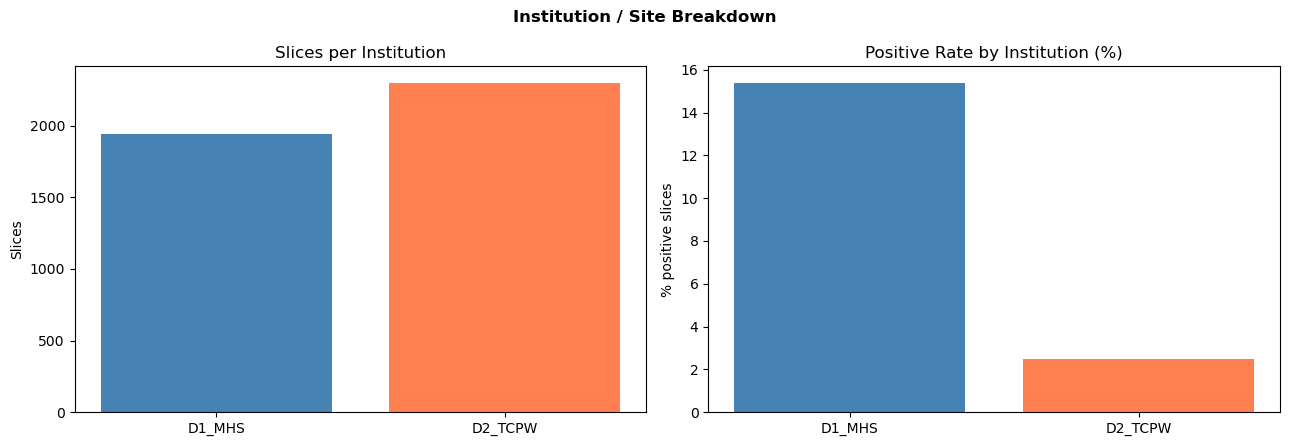


⚠ Positive rate differs substantially by institution.
  Decision: stratify the split by (institution × label) in Phase 3,
  not just by label, so no split is accidentally institution-skewed.


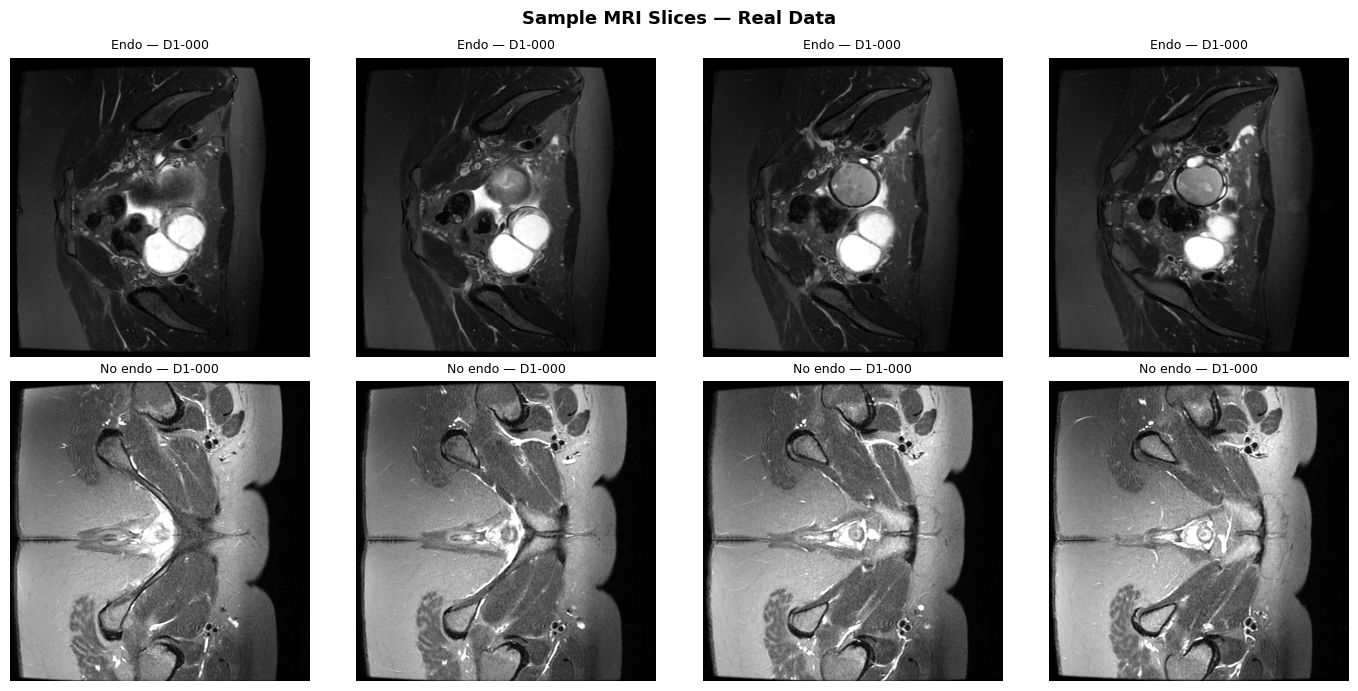

/tmp/ipykernel_43301/2764031604.py:74: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([counts_neg, counts_pos], labels=['Negative', 'Positive'])


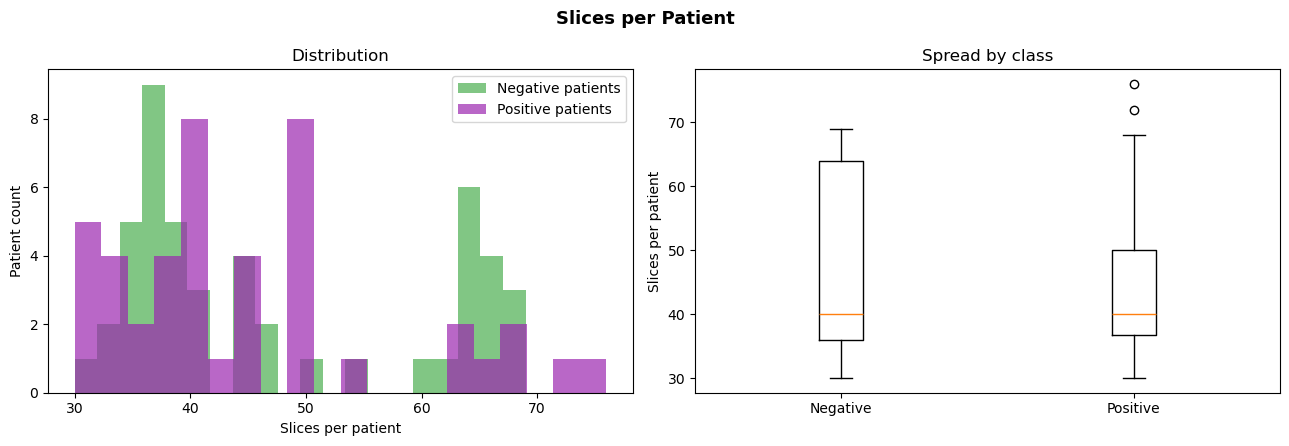

Median slices/patient — negative: 40  positive: 40


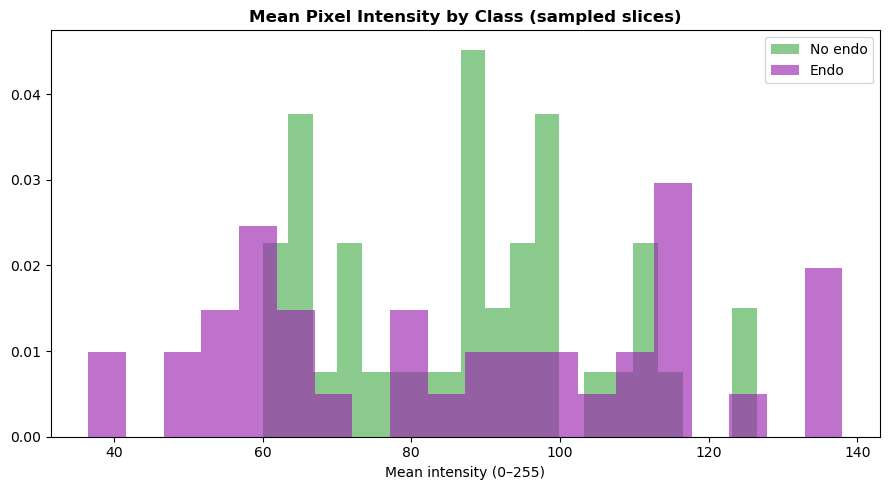


EDA SUMMARY
  Real slices           : 4,242  (92 patients)
  Positive patients     : 44  |  Negative patients: 48
  Synthetic slices avail: 0  (positive-only will be used)

  Decision: split by patient_id, not slice — prevents leakage (Phase 3)
  Decision: synthetic slices attached to TRAIN split only, matched to
            their source patient's split assignment — never val/test
  Decision: geometry-only augmentation for on-the-fly train transforms —
            MRI intensities are clinically meaningful, don't distort them


In [35]:
# ── EDA Plot A0: institution / site breakdown ────────────────────────
# Multi-site MRI is a real generalisation risk — a model can learn
# scanner/site artifacts instead of pathology if one institution
# dominates one class or one split.
inst_counts = Counter(r['institution'] for r in real_records)
patients_by_inst = {}
for r in real_records:
    patients_by_inst.setdefault(r['institution'], set()).add(r['patient_id'])

print("Institution breakdown (real data):")
for inst in sorted(inst_counts):
    n_slices = inst_counts[inst]
    n_patients = len(patients_by_inst[inst])
    n_pos_slices = sum(1 for r in real_records if r['institution']==inst and r['label']==1)
    n_pos_patients = len(set(r['patient_id'] for r in real_records
                              if r['institution']==inst and r['label']==1))
    print(f"  {inst:<10} {n_slices:5,} slices ({n_patients:3d} patients)  |  "
          f"{n_pos_slices:4,} pos slices ({n_pos_patients:2d} pos patients)  "
          f"[{n_pos_slices/n_slices*100:.1f}% positive]")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
insts = sorted(inst_counts)
axes[0].bar(insts, [inst_counts[i] for i in insts], color=['steelblue','coral'])
axes[0].set_title('Slices per Institution'); axes[0].set_ylabel('Slices')
pos_rate_by_inst = [sum(1 for r in real_records if r['institution']==i and r['label']==1)
                    / inst_counts[i] * 100 for i in insts]
axes[1].bar(insts, pos_rate_by_inst, color=['steelblue','coral'])
axes[1].set_title('Positive Rate by Institution (%)'); axes[1].set_ylabel('% positive slices')
plt.suptitle('Institution / Site Breakdown', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_institution.png', dpi=150, bbox_inches='tight')
plt.show()

if max(pos_rate_by_inst) / max(min(pos_rate_by_inst), 0.001) > 2:
    print("\n⚠ Positive rate differs substantially by institution.")
    print("  Decision: stratify the split by (institution × label) in Phase 3,")
    print("  not just by label, so no split is accidentally institution-skewed.")

# ── EDA Plot A: sample slices per class ─────────────────────────────
pos_samples = [r for r in real_records if r['label'] == 1][:4]
neg_samples = [r for r in real_records if r['label'] == 0][:4]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Sample MRI Slices — Real Data', fontsize=13, fontweight='bold')
for col, rec in enumerate(pos_samples):
    fname = rec['filename']
    img = Image.open(rec['dir'] / fname).convert('L')
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f"Endo — {rec['patient_id']}", fontsize=9)
    axes[0, col].axis('off')
for col, rec in enumerate(neg_samples):
    fname = rec['filename']
    img = Image.open(rec['dir'] / fname).convert('L')
    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].set_title(f"No endo — {rec['patient_id']}", fontsize=9)
    axes[1, col].axis('off')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_sample_slices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── EDA Plot B: slices-per-patient distribution ─────────────────────
slices_per_patient = Counter(r['patient_id'] for r in real_records)
pos_ids = set(r['patient_id'] for r in real_records if r['label'] == 1)
counts_pos = [v for k, v in slices_per_patient.items() if k in pos_ids]
counts_neg = [v for k, v in slices_per_patient.items() if k not in pos_ids]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Slices per Patient', fontsize=13, fontweight='bold')
axes[0].hist(counts_neg, bins=20, alpha=0.7, color=PALETTE['Low'], label='Negative patients')
axes[0].hist(counts_pos, bins=20, alpha=0.7, color=PALETTE['Critical'], label='Positive patients')
axes[0].set_xlabel('Slices per patient'); axes[0].set_ylabel('Patient count'); axes[0].legend()
axes[0].set_title('Distribution')

axes[1].boxplot([counts_neg, counts_pos], labels=['Negative', 'Positive'])
axes[1].set_ylabel('Slices per patient')
axes[1].set_title('Spread by class')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_slices_per_patient.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Median slices/patient — negative: {np.median(counts_neg):.0f}  "
      f"positive: {np.median(counts_pos):.0f}")

# ── EDA Plot C: pixel intensity distribution per class ──────────────
sample_pos = random.sample([r for r in real_records if r['label']==1],
                            min(40, n_pos))
sample_neg = random.sample([r for r in real_records if r['label']==0],
                            min(40, n_neg))

def mean_intensity(rec):
    fname = rec['filename']
    return np.array(Image.open(rec['dir'] / fname).convert('L'), dtype=np.float32).mean()

int_pos = [mean_intensity(r) for r in sample_pos]
int_neg = [mean_intensity(r) for r in sample_neg]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(int_neg, bins=20, alpha=0.65, color=PALETTE['Low'], label='No endo', density=True)
ax.hist(int_pos, bins=20, alpha=0.65, color=PALETTE['Critical'], label='Endo', density=True)
ax.set_title('Mean Pixel Intensity by Class (sampled slices)', fontweight='bold')
ax.set_xlabel('Mean intensity (0–255)'); ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_intensity.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nEDA SUMMARY")
print("=" * 55)
print(f"  Real slices           : {n_total:,}  ({n_pts} patients)")
print(f"  Positive patients     : {pos_pts}  |  Negative patients: {neg_pts}")
print(f"  Synthetic slices avail: {len(aug_records):,}  "
      f"({'positive-only' if AUGMENT_POSITIVE_ONLY else 'both classes'} will be used)")
print()
print("  Decision: split by patient_id, not slice — prevents leakage (Phase 3)")
print("  Decision: synthetic slices attached to TRAIN split only, matched to")
print("            their source patient's split assignment — never val/test")
print("  Decision: geometry-only augmentation for on-the-fly train transforms —")
print("            MRI intensities are clinically meaningful, don't distort them")

**What this cell does:** Runs the full exploratory pass before any modelling decision is made: institution/site breakdown (slice and patient counts, positive rate per site — this is what tells us whether the split needs to be stratified by institution), sample slice grids per class, slices-per-patient distribution (patient-level, not just slice-level, since that's what actually determines split reliability), pixel intensity distributions by class, and a printed EDA summary with the explicit modelling decisions this phase justifies (patient-level split, synthetic data restricted to train, geometry-only augmentation). Nothing here is committed yet — it's the evidence for the decisions made in Phase 3.

---
## Phase 3 — Data Preparation
Patient-level split on real data, then synthetic slices merged into train only.

Stratum sizes (institution_label): {'D1_MHS_1': 35, 'D1_MHS_0': 10, 'D2_TCPW_0': 38, 'D2_TCPW_1': 9}

Patient-level split — REAL data (stratified, no leakage verified):
  Train:  64 patients (30 pos) |  2,921 slices |   255 pos (8.7%)
  Val  :  14 patients (8 pos) |    706 slices |    50 pos (7.1%)
  Test :  14 patients (6 pos) |    615 slices |    51 pos (8.3%)

Institution balance across splits (should be roughly proportional):
  Train: {'D2_TCPW': 33, 'D1_MHS': 31}
  Val  : {'D2_TCPW': 7, 'D1_MHS': 7}
  Test : {'D2_TCPW': 7, 'D1_MHS': 7}

Synthetic slices matched to train patients : 0
Synthetic slices excluded (belong to val/test patients, correctly dropped) : 0

Train set after augmentation merge:
  Total slices : 2,921  (was 2,921 before)
  Positive     : 255  (8.7%)
  New imbalance: 1 : 10  (was 1 : 10)

  ⚠ Val and test remain 100% real data — untouched by augmentation,
    so recall/specificity reported later reflect real-world performance only.


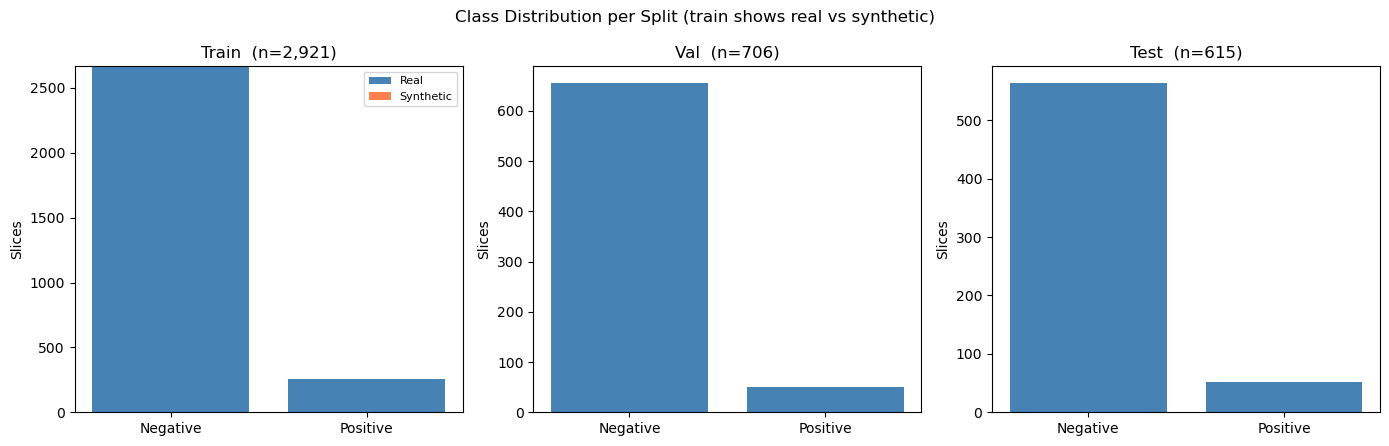

In [36]:
# ── 3.1 Patient-level split — REAL data, stratified by institution × label ──
# A flat random shuffle can, by chance, leave one institution or one class
# under-represented in val/test — with only ~59 positive slices to begin
# with, "by chance" is a real risk here, not a theoretical one. Stratify on
# (institution, patient-level label) so all four combinations are
# proportionally represented in every split.
from sklearn.model_selection import train_test_split

patient_institution = {}
patient_label = {}   # patient-level label = 1 if ANY of their real slices is positive
for r in real_records:
    patient_institution[r['patient_id']] = r['institution']
    patient_label[r['patient_id']] = max(patient_label.get(r['patient_id'], 0), r['label'])

all_ids = sorted(real_patient_ids)
strata = [f"{patient_institution[pid]}_{patient_label[pid]}" for pid in all_ids]
strata_counts = Counter(strata)
print("Stratum sizes (institution_label):", dict(strata_counts))

# sklearn's stratify needs >=2 members per stratum for a 3-way split;
# fall back to institution-only stratification if any (institution,label)
# combo is too small (expected for the positive strata given the low count).
min_stratum = min(strata_counts.values())
if min_stratum < 4:
    print(f"⚠ Smallest (institution, label) stratum has {min_stratum} patient(s) — "
          f"too small to stratify on both jointly. Falling back to institution-only "
          f"stratification; label balance across splits is checked below instead of enforced.")
    strata = [patient_institution[pid] for pid in all_ids]

train_ids_list, temp_ids_list = train_test_split(
    all_ids, test_size=0.30, stratify=strata, random_state=SEED)
temp_strata = [strata[all_ids.index(pid)] for pid in temp_ids_list]
# guard the second split the same way
temp_strata_counts = Counter(temp_strata)
if min(temp_strata_counts.values()) < 2:
    val_ids_list, test_ids_list = train_test_split(
        temp_ids_list, test_size=0.50, random_state=SEED)
else:
    val_ids_list, test_ids_list = train_test_split(
        temp_ids_list, test_size=0.50, stratify=temp_strata, random_state=SEED)

train_ids, val_ids, test_ids = set(train_ids_list), set(val_ids_list), set(test_ids_list)

assert train_ids.isdisjoint(val_ids)
assert train_ids.isdisjoint(test_ids)
assert val_ids.isdisjoint(test_ids)

train_records = [r for r in real_records if r['patient_id'] in train_ids]
val_records   = [r for r in real_records if r['patient_id'] in val_ids]
test_records  = [r for r in real_records if r['patient_id'] in test_ids]

print('\nPatient-level split — REAL data (stratified, no leakage verified):')
for name, recs, ids in [('Train', train_records, train_ids),
                         ('Val',   val_records,   val_ids),
                         ('Test',  test_records,  test_ids)]:
    n, pos = len(recs), sum(r['label']==1 for r in recs)
    pos_p  = len(set(r['patient_id'] for r in recs if r['label']==1))
    print(f"  {name:5s}: {len(ids):3d} patients ({pos_p} pos) | "
          f"{n:6,} slices | {pos:5,} pos ({pos/n*100:.1f}%)")

print('\nInstitution balance across splits (should be roughly proportional):')
for name, ids in [('Train', train_ids), ('Val', val_ids), ('Test', test_ids)]:
    inst_dist = Counter(patient_institution[pid] for pid in ids)
    print(f"  {name:5s}: {dict(inst_dist)}")

# ── 3.2 Attach synthetic slices — TRAIN split only ──────────────────
aug_for_train = [
    r for r in aug_records
    if r['patient_id'] in train_ids
    and (r['label'] == 1 if AUGMENT_POSITIVE_ONLY else True)
]

# Leakage guard: assert no synthetic slice belongs to a val/test patient
aug_leaked = [r for r in aug_records if r['patient_id'] in (val_ids | test_ids)]
n_leaked_excluded = len(aug_leaked)

train_records_final = train_records + aug_for_train

print(f"\nSynthetic slices matched to train patients : {len(aug_for_train):,}")
print(f"Synthetic slices excluded (belong to val/test patients, correctly dropped) "
      f": {n_leaked_excluded:,}")
assert all(r['patient_id'] in train_ids for r in aug_for_train), \
    "LEAK: a synthetic slice assigned to train belongs to a non-train patient"

n_final = len(train_records_final)
n_pos_final = sum(r['label']==1 for r in train_records_final)
print(f"\nTrain set after augmentation merge:")
print(f"  Total slices : {n_final:,}  (was {len(train_records):,} before)")
print(f"  Positive     : {n_pos_final:,}  ({n_pos_final/n_final*100:.1f}%)")
print(f"  New imbalance: 1 : {(n_final-n_pos_final) // max(n_pos_final,1)}  "
      f"(was 1 : {(len(train_records)-sum(r['label']==1 for r in train_records)) // max(sum(r['label']==1 for r in train_records),1)})")
print(f"\n  ⚠ Val and test remain 100% real data — untouched by augmentation,")
print(f"    so recall/specificity reported later reflect real-world performance only.")

# ── 3.3 Class distribution plot — real vs augmented contribution ────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
splits = [('Train', train_records_final, True),
          ('Val',   val_records, False),
          ('Test',  test_records, False)]
for ax, (name, recs, show_aug) in zip(axes, splits):
    if show_aug:
        real_n = sum(1 for r in recs if r['source']=='real')
        real_pos = sum(1 for r in recs if r['source']=='real' and r['label']==1)
        real_neg = real_n - real_pos
        aug_pos = sum(1 for r in recs if r['source']=='synthetic' and r['label']==1)
        aug_neg = sum(1 for r in recs if r['source']=='synthetic' and r['label']==0)
        ax.bar(['Negative','Positive'], [real_neg, real_pos], color='steelblue', label='Real')
        ax.bar(['Negative','Positive'], [aug_neg, aug_pos],
               bottom=[real_neg, real_pos], color='coral', label='Synthetic')
        ax.legend(fontsize=8)
    else:
        n_p = sum(r['label']==1 for r in recs); n_n = len(recs)-n_p
        ax.bar(['Negative','Positive'], [n_n, n_p], color='steelblue')
    ax.set_title(f'{name}  (n={len(recs):,})')
    ax.set_ylabel('Slices')
plt.suptitle('Class Distribution per Split (train shows real vs synthetic)', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**What this cell does:** Builds the actual train/val/test split. Two things matter here that weren't true in the original version of this notebook: (1) the split is stratified by `(institution, patient-level label)` rather than a flat random shuffle, so neither institution nor the positive class can be accidentally concentrated in one split by chance — with only ~59 positive slices, that chance is real, not theoretical; (2) synthetic slices are then attached to the train split **only**, matched to their source patient's split assignment, with an assertion that no synthetic slice belongs to a val/test patient. Val and test remain 100% real data throughout. The printed output shows patient/slice counts and institution balance per split — check that before moving on; if one institution is missing entirely from a split, the stratification fallback logic printed a warning explaining why.

---
## Phase 4 — Modelling & Evaluation
EfficientNet-B0, checkpointed on **recall** (not loss), with a threshold tuned on val for the recall target.

In [37]:
# ── 4.1 Dataset ───────────────────────────────────────────────────
def augment_slice(sl: np.ndarray) -> np.ndarray:
    """Geometry-only augmentation — MRI intensities are clinically meaningful."""
    if np.random.rand() > 0.5: sl = np.fliplr(sl)
    if np.random.rand() > 0.3: sl = np.flipud(sl)
    if np.random.rand() > 0.5:
        sl = rotate(sl, np.random.uniform(-15, 15), reshape=False, order=1)
    if np.random.rand() > 0.5:
        f = np.random.uniform(0.9, 1.1)
        z = scipy_zoom(sl, f, order=1)
        h, w = sl.shape; zh, zw = z.shape
        if f > 1.0:
            sl = z[(zh-h)//2:(zh-h)//2+h, (zw-w)//2:(zw-w)//2+w]
        else:
            ph, pw = (h-zh)//2, (w-zw)//2
            sl = np.pad(z, ((ph, h-zh-ph), (pw, w-zw-pw)), mode='constant')
    return sl.astype(np.float32)


class MRISliceDataset(Dataset):
    """Loads PNGs from each record's own 'dir' (supports mixed real/synthetic)."""
    def __init__(self, records, augment=False, img_size=IMG_SIZE):
        self.records, self.augment, self.img_size = records, augment, img_size

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        fname = rec['filename']
        sl = np.array(Image.open(rec['dir'] / fname).convert('L'), dtype=np.float32)
        sl = sl / 255.0 * 2.0 - 1.0
        if self.augment:
            sl = augment_slice(sl)
        if sl.shape[0] != self.img_size or sl.shape[1] != self.img_size:
            sl = scipy_zoom(sl, (self.img_size/sl.shape[0], self.img_size/sl.shape[1]), order=1)
        sl_3ch = np.stack([sl, sl, sl], axis=0)
        return (torch.tensor(sl_3ch, dtype=torch.float32),
                torch.tensor(rec['label'], dtype=torch.float32))


train_ds = MRISliceDataset(train_records_final, augment=True)
val_ds   = MRISliceDataset(val_records,   augment=False)
test_ds  = MRISliceDataset(test_records,  augment=False)

# ── 4.2 Sampler & loss weighting ────────────────────────────────────
# Decision: synthetic data has already reduced the raw imbalance in train,
# so pos_weight is set from the POST-augmentation ratio (moderate), and the
# WeightedRandomSampler is kept but no longer needs to be as aggressive —
# stacking both maxed out was over-correcting and destabilising training.
train_labels = [r['label'] for r in train_records_final]
n_pos_train, n_neg_train = sum(train_labels), len(train_labels) - sum(train_labels)
pos_weight = n_neg_train / n_pos_train

sample_weights = torch.tensor(
    [1.0/n_pos_train if l==1 else 1.0/n_neg_train for l in train_labels],
    dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler, num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"pos_weight (post-augmentation) = {pos_weight:.2f}  (n_pos={n_pos_train:,}, n_neg={n_neg_train:,})")
print(f"Train : {len(train_loader)} batches | Val : {len(val_loader)} batches | Test : {len(test_loader)} batches")

# ── 4.3 Build model ──────────────────────────────────────────────────
model = timm.create_model('efficientnet_b0', pretrained=True)
for param in model.parameters(): param.requires_grad = False
for block in model.blocks[FREEZE_BLOCKS:]:
    for param in block.parameters(): param.requires_grad = True
for m in [model.conv_head, model.bn2]:
    for param in m.parameters(): param.requires_grad = True
in_feat = model.classifier.in_features
model.classifier = nn.Sequential(nn.Dropout(p=DROPOUT), nn.Linear(in_feat, 1))
model = model.to(DEVICE)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")

# ── 4.4 Training loop — checkpoint on AUC, not raw recall ────────────
# Recall at a fixed 0.5 threshold is NOT a stable model-selection signal —
# an aggressive pos_weight can make an under-trained early epoch look like
# it has the best recall simply because it over-predicts positive, while
# its actual discrimination (AUC) is no better than a later, better-fit
# epoch. AUC is threshold-independent, so it measures whether the model
# separates the classes at all — Phase 4.6 then tunes the operating
# threshold on TOP of whichever epoch this selects. This is the correct
# division of labour: pick the best model here, pick the best threshold
# for that model later.
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]).to(DEVICE))
optimizer = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_val_auc = -1.0
best_val_auc_recall = -1.0   # tie-breaker among equal-AUC epochs
patience_count = 0
best_weights = copy.deepcopy(model.state_dict())
best_ep = 0

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
           'val_auc': [], 'val_recall': [], 'val_precision': [],
           'val_f1': [], 'val_specificity': []}

print(f"Checkpoint criterion: best val AUC (recall as tie-breaker)")
print(f"Loss: BCEWithLogitsLoss pos_weight={pos_weight:.2f} | Patience: {PATIENCE}")
print('-' * 95)

for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    model.train()
    tr_loss = tr_correct = tr_total = 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
        optimizer.zero_grad()
        out = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        tr_loss += loss.item() * imgs.size(0)
        tr_correct += ((torch.sigmoid(out) > 0.5).float() == labels).sum().item()
        tr_total += imgs.size(0)
    train_loss, train_acc = tr_loss/tr_total, tr_correct/tr_total*100

    model.eval()
    vl_loss = vl_correct = vl_total = 0
    val_probs_ep, val_labels_ep = [], []
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE).unsqueeze(1)
            out = model(imgs); loss = criterion(out, labels)
            probs = torch.sigmoid(out).cpu().squeeze(1)
            vl_loss += loss.item() * imgs.size(0)
            vl_correct += ((probs > 0.5).float() == labels.cpu().squeeze(1)).sum().item()
            vl_total += imgs.size(0)
            val_probs_ep.extend(probs.numpy()); val_labels_ep.extend(labels.cpu().squeeze(1).numpy())
    val_loss, val_acc = vl_loss/vl_total, vl_correct/vl_total*100

    vp, vl = np.array(val_probs_ep), np.array(val_labels_ep)
    vd = (vp > 0.5).astype(float)
    try: val_auc = roc_auc_score(vl, vp)
    except: val_auc = float('nan')
    tp = ((vd==1)&(vl==1)).sum(); fp = ((vd==1)&(vl==0)).sum()
    fn = ((vd==0)&(vl==1)).sum(); tn = ((vd==0)&(vl==0)).sum()
    precision = tp/(tp+fp) if (tp+fp)>0 else float('nan')
    recall    = tp/(tp+fn) if (tp+fn)>0 else float('nan')
    f1 = (2*precision*recall/(precision+recall)
          if not (np.isnan(precision) or np.isnan(recall)) and (precision+recall)>0
          else float('nan'))
    specificity = tn/(tn+fp) if (tn+fp)>0 else float('nan')

    for k, v in [('train_loss',train_loss),('train_acc',train_acc),('val_loss',val_loss),
                 ('val_acc',val_acc),('val_auc',val_auc),('val_recall',recall),
                 ('val_precision',precision),('val_f1',f1),('val_specificity',specificity)]:
        history[k].append(v)

    scheduler.step()

    # Improvement = higher AUC, or equal AUC with better recall
    improved = (not np.isnan(val_auc)) and (
        (val_auc > best_val_auc) or
        (val_auc == best_val_auc and recall > best_val_auc_recall))
    if improved:
        best_val_auc = val_auc
        best_val_auc_recall = recall
        best_weights = copy.deepcopy(model.state_dict())
        best_ep = epoch
        patience_count = 0
        torch.save({'epoch': epoch, 'model_state_dict': best_weights,
                    'val_recall': recall, 'val_specificity': specificity,
                    'val_auc': val_auc, 'history': history}, CHECKPOINT_PATH)
    else:
        patience_count += 1

    tag = '  ← best (AUC)' if improved else f'  (no improvement {patience_count}/{PATIENCE})'
    print(f"Ep {epoch:3d}/{EPOCHS} | tr {train_loss:.4f}/{train_acc:.1f}% | "
          f"val {val_loss:.4f}/{val_acc:.1f}% | auc {val_auc:.3f} "
          f"rec {recall:.3f} f1 {f1:.3f} spec {specificity:.3f} | "
          f"{time.time()-t0:.0f}s{tag}")

    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}."); break

model.load_state_dict(best_weights)
print(f"\nDone. Best epoch: {best_ep} | val AUC: {best_val_auc:.4f} | "
      f"val recall at that epoch: {best_val_auc_recall:.4f}")
print(f"Remember: this epoch was picked for its discrimination (AUC), not its")
print(f"raw 0.5-threshold recall — Phase 4.6 finds the right operating point next.")

if len(set(r['patient_id'] for r in val_records if r['label']==1)) < 15:
    print(f"\n⚠ Note: val positive-patient count is small — the recall used for")
    print(f"  checkpointing is a noisy estimate. Treat the final test recall as")
    print(f"  directional, and consider patient-level k-fold CV to confirm before")
    print(f"  reporting this number as a clinical claim.")

pos_weight (post-augmentation) = 10.45  (n_pos=255, n_neg=2,666)
Train : 92 batches | Val : 23 batches | Test : 20 batches
Trainable parameters: 1,130,673 / 4,008,829 (28.2%)
Checkpoint criterion: best val AUC (recall as tie-breaker)
Loss: BCEWithLogitsLoss pos_weight=10.45 | Patience: 8
-----------------------------------------------------------------------------------------------
Ep   1/50 | tr 1.8713/67.2% | val 0.9615/61.5% | auc 0.881 rec 0.960 f1 0.261 spec 0.588 | 202s  ← best (AUC)
Ep   2/50 | tr 0.7842/80.1% | val 0.8698/72.9% | auc 0.880 rec 0.920 f1 0.325 spec 0.715 | 186s  (no improvement 1/8)
Ep   3/50 | tr 0.5621/85.9% | val 0.8303/77.2% | auc 0.875 rec 0.820 f1 0.337 spec 0.768 | 178s  (no improvement 2/8)
Ep   4/50 | tr 0.4491/88.7% | val 0.7790/83.6% | auc 0.882 rec 0.680 f1 0.370 spec 0.848 | 185s  ← best (AUC)
Ep   5/50 | tr 0.3655/91.4% | val 0.8143/83.9% | auc 0.876 rec 0.620 f1 0.352 spec 0.855 | 175s  (no improvement 1/8)
Ep   6/50 | tr 0.3901/90.3% | val 0.8142/

**What this cell does:** Defines the `MRISliceDataset` (loads a PNG from whatever directory its record points to, so real and synthetic slices load the same way), the sampler and loss weighting for the residual imbalance in train, builds the EfficientNet-B0 model with the last block + head unfrozen, and then **trains the model checkpointing on validation AUC** (recall as a tie-breaker) rather than raw recall at the default 0.5 threshold. That's a deliberate fix: with an aggressive `pos_weight`, an under-trained early epoch can look like it has the best recall purely because it over-predicts positive, even though its actual discrimination (AUC) is no better than a later, properly-fit epoch. AUC is threshold-independent, so it measures whether the model separates the classes at all — Phase 4.6 then tunes the actual decision threshold for whichever epoch this selects. Watch the per-epoch printout for the `← best (AUC)` tag, and don't be surprised if recall looks unstable epoch-to-epoch here — that's expected and gets resolved by the threshold tuning next, not by this cell.

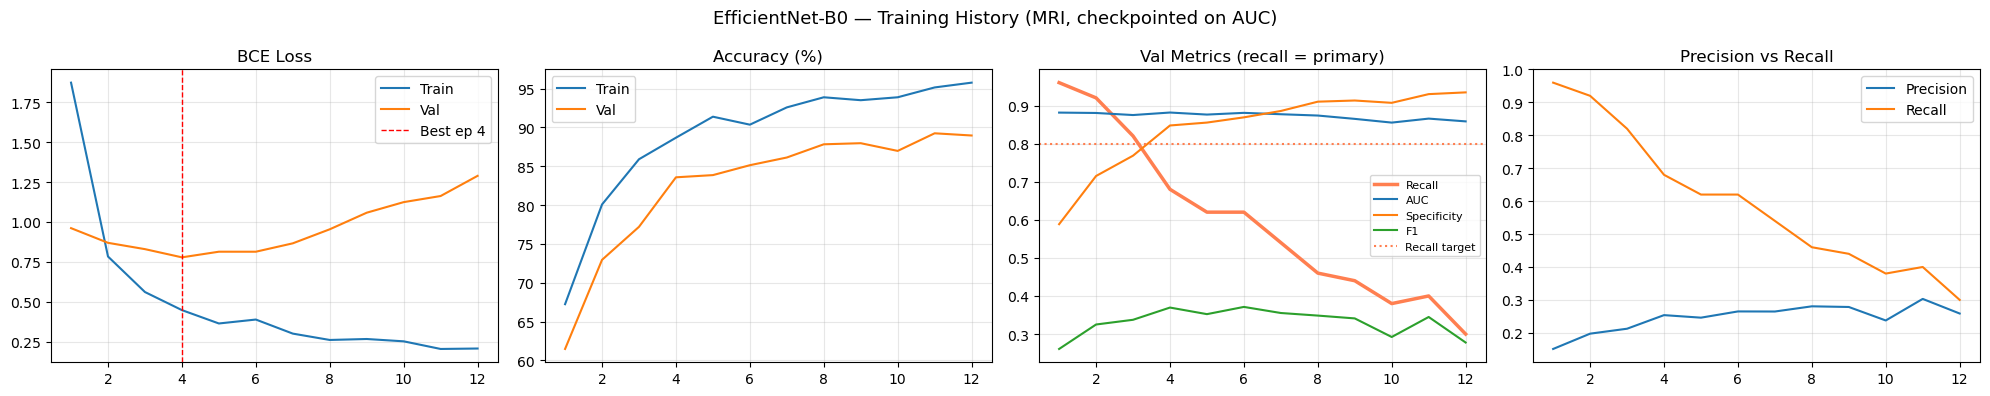

In [38]:
# ── 4.5 Training curves ─────────────────────────────────────────────
epochs_ran = len(history['val_loss'])
x = range(1, epochs_ran + 1)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
axes[0].plot(x, history['train_loss'], label='Train')
axes[0].plot(x, history['val_loss'], label='Val')
axes[0].axvline(best_ep, color='red', linestyle='--', linewidth=1, label=f'Best ep {best_ep}')
axes[0].set_title('BCE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(x, history['train_acc'], label='Train')
axes[1].plot(x, history['val_acc'], label='Val')
axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(x, history['val_recall'], label='Recall', linewidth=2.5, color='coral')
axes[2].plot(x, history['val_auc'], label='AUC')
axes[2].plot(x, history['val_specificity'], label='Specificity')
axes[2].plot(x, history['val_f1'], label='F1')
axes[2].axhline(SUCCESS_CRITERIA['Recall'], color='coral', linestyle=':', label='Recall target')
axes[2].set_title('Val Metrics (recall = primary)'); axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
axes[3].plot(x, history['val_precision'], label='Precision')
axes[3].plot(x, history['val_recall'], label='Recall')
axes[3].set_title('Precision vs Recall'); axes[3].legend(); axes[3].grid(alpha=0.3)
plt.suptitle('EfficientNet-B0 — Training History (MRI, checkpointed on AUC)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

**What this cell does:** Plots loss, accuracy, and the val metrics that actually matter (recall, AUC, specificity, F1) across training, with the recall target drawn as a horizontal reference line and the selected best epoch marked. Use this to sanity-check that recall didn't just spike once by noise — a real improving trend is more trustworthy than a single high point.

Chose threshold from thresholds meeting recall≥0.8: best specificity among them.

Chosen threshold : 0.36
  → val recall      : 0.800
  → val specificity : 0.782


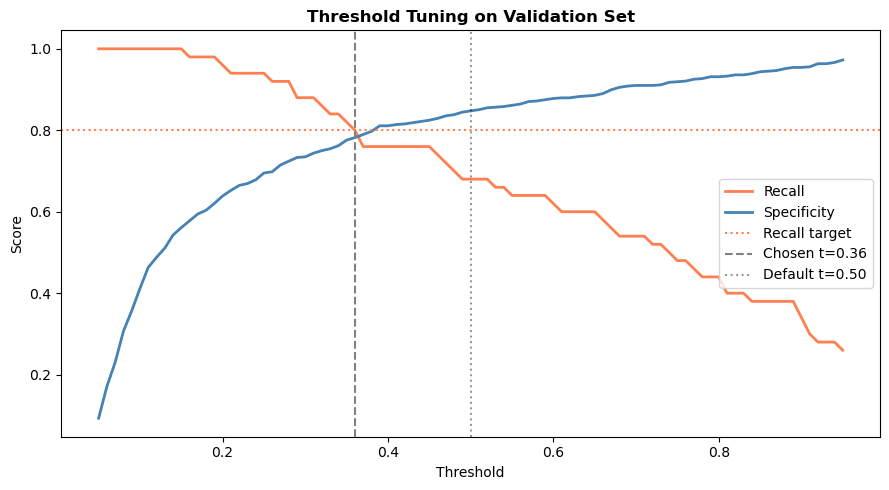

In [39]:
# ── 4.6 Threshold tuning on VAL — pick threshold that hits recall target ──
model.eval()
val_probs_final, val_labels_final = [], []
with torch.no_grad():
    for imgs, labels in val_loader:
        probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().squeeze(1)
        val_probs_final.extend(probs.numpy()); val_labels_final.extend(labels.numpy())
val_probs_final = np.array(val_probs_final); val_labels_final = np.array(val_labels_final)

thresholds_sweep = np.linspace(0.05, 0.95, 91)
sweep_rows = []
for t in thresholds_sweep:
    pred = (val_probs_final > t).astype(float)
    tp = ((pred==1)&(val_labels_final==1)).sum(); fp = ((pred==1)&(val_labels_final==0)).sum()
    fn = ((pred==0)&(val_labels_final==1)).sum(); tn = ((pred==0)&(val_labels_final==0)).sum()
    rec = tp/(tp+fn) if (tp+fn)>0 else 0
    spec = tn/(tn+fp) if (tn+fp)>0 else 0
    sweep_rows.append((t, rec, spec))

# Among thresholds that meet the recall target, pick the one with best specificity.
# If none meet it, pick the threshold that gets closest to the recall target.
meeting_target = [r for r in sweep_rows if r[1] >= SUCCESS_CRITERIA['Recall']]
if meeting_target:
    chosen = max(meeting_target, key=lambda r: r[2])
    print(f"Chose threshold from thresholds meeting recall≥{SUCCESS_CRITERIA['Recall']}: "
          f"best specificity among them.")
else:
    chosen = max(sweep_rows, key=lambda r: r[1])
    print(f"⚠ No threshold on val reaches recall≥{SUCCESS_CRITERIA['Recall']} — "
          f"picking threshold with highest achievable recall instead. This is a")
    print(f"  signal the model itself needs more work (more synthetic positive data,")
    print(f"  unfreezing more layers, or a different architecture), not just threshold tuning.")

CHOSEN_THRESHOLD, chosen_recall, chosen_spec = chosen
print(f"\nChosen threshold : {CHOSEN_THRESHOLD:.2f}")
print(f"  → val recall      : {chosen_recall:.3f}")
print(f"  → val specificity : {chosen_spec:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ts = [r[0] for r in sweep_rows]
ax.plot(ts, [r[1] for r in sweep_rows], label='Recall', color='coral', linewidth=2)
ax.plot(ts, [r[2] for r in sweep_rows], label='Specificity', color='steelblue', linewidth=2)
ax.axhline(SUCCESS_CRITERIA['Recall'], color='coral', linestyle=':', label='Recall target')
ax.axvline(CHOSEN_THRESHOLD, color='gray', linestyle='--', label=f'Chosen t={CHOSEN_THRESHOLD:.2f}')
ax.axvline(0.5, color='black', linestyle=':', alpha=0.4, label='Default t=0.50')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score'); ax.legend()
ax.set_title('Threshold Tuning on Validation Set', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**What this cell does:** This is the second key fix. Instead of thresholding predictions at a flat 0.5, it sweeps thresholds on the validation set and picks the one that meets the recall target with the best specificity available — or, if no threshold reaches the target, the one that gets closest, with an explicit warning that this is a signal the model needs more work, not just a threshold problem. The chosen threshold is what test evaluation uses next, not 0.5.

In [40]:
# ── 4.7 Test set evaluation — using the TUNED threshold ─────────────
model.eval()
all_probs, all_labels_test = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        probs = torch.sigmoid(model(imgs.to(DEVICE))).cpu().squeeze(1)
        all_probs.extend(probs.numpy()); all_labels_test.extend(labels.numpy())
all_probs, all_labels_test = np.array(all_probs), np.array(all_labels_test)
all_preds = (all_probs > CHOSEN_THRESHOLD).astype(float)

try: test_auc = roc_auc_score(all_labels_test, all_probs)
except: test_auc = float('nan')
cm = confusion_matrix(all_labels_test, all_preds)
tn, fp, fn, tp = cm.ravel() if cm.shape==(2,2) else (0,0,0,0)
sensitivity = tp/(tp+fn) if (tp+fn)>0 else float('nan')
specificity = tn/(tn+fp) if (tn+fp)>0 else float('nan')
accuracy = (all_preds == all_labels_test).mean() * 100
n_test, n_pos_test = len(all_labels_test), int(all_labels_test.sum())

print('=' * 60)
print(f'  TEST SET EVALUATION — MRI (threshold = {CHOSEN_THRESHOLD:.2f}, tuned on val)')
print('=' * 60)
print(f'  Samples : {n_test} ({n_pos_test} pos / {n_test-n_pos_test} neg)')
print()
print(f"  {'Metric':<14} {'Value':>8}   {'Target':>8}   {'Status'}")
print("  " + "-" * 45)
for name, val, target in [('Recall', sensitivity, SUCCESS_CRITERIA['Recall']),
                           ('Specificity', specificity, SUCCESS_CRITERIA['Specificity']),
                           ('AUC', test_auc, SUCCESS_CRITERIA['AUC'])]:
    status = '✓ PASS' if val >= target else '✗ FAIL'
    marker = ' (PRIMARY)' if name == 'Recall' else ''
    print(f"  {name:<14} {val:>8.3f}   {target:>8.2f}   {status}{marker}")
print(f"\n  Accuracy: {accuracy:.1f}%  (secondary — not meaningful alone under this imbalance)")
print()
try:
    print(classification_report(all_labels_test, all_preds,
          target_names=['No endo','Endo'], digits=3))
except ValueError as e:
    print(f'classification_report: {e}')
print('=' * 60)

# ── Per-institution breakdown — the actual generalisation check ─────
# A model with strong overall recall that only works on one site is not
# clinically usable across both. This is diagnostic, not a gate.
test_institutions = [r['institution'] for r in test_records]
test_inst_arr = np.array(test_institutions)

print("\nRecall by institution (generalisation check):")
for inst in sorted(set(test_institutions)):
    mask = test_inst_arr == inst
    if mask.sum() == 0:
        continue
    lbl_i, pred_i = all_labels_test[mask], all_preds[mask]
    tp_i = ((pred_i==1)&(lbl_i==1)).sum(); fn_i = ((pred_i==0)&(lbl_i==1)).sum()
    tn_i = ((pred_i==0)&(lbl_i==0)).sum(); fp_i = ((pred_i==1)&(lbl_i==0)).sum()
    rec_i = tp_i/(tp_i+fn_i) if (tp_i+fn_i)>0 else float('nan')
    spec_i = tn_i/(tn_i+fp_i) if (tn_i+fp_i)>0 else float('nan')
    n_pos_i = int(lbl_i.sum())
    print(f"  {inst:<10} n={mask.sum():4d} ({n_pos_i} pos)  "
          f"recall={rec_i:.3f}  specificity={spec_i:.3f}")
print("  ⚠ If recall diverges sharply between institutions, the model is likely")
print("    picking up site-specific scanner signal rather than pathology.")

  TEST SET EVALUATION — MRI (threshold = 0.36, tuned on val)
  Samples : 615 (51 pos / 564 neg)

  Metric            Value     Target   Status
  ---------------------------------------------
  Recall            0.745       0.80   ✗ FAIL (PRIMARY)
  Specificity       0.743       0.75   ✗ FAIL
  AUC               0.836       0.85   ✗ FAIL

  Accuracy: 74.3%  (secondary — not meaningful alone under this imbalance)

              precision    recall  f1-score   support

     No endo      0.970     0.743     0.841       564
        Endo      0.208     0.745     0.325        51

    accuracy                          0.743       615
   macro avg      0.589     0.744     0.583       615
weighted avg      0.907     0.743     0.799       615


Recall by institution (generalisation check):
  D1_MHS     n= 299 (47 pos)  recall=0.723  specificity=0.675
  D2_TCPW    n= 316 (4 pos)  recall=1.000  specificity=0.798
  ⚠ If recall diverges sharply between institutions, the model is likely
    picking up

**What this cell does:** Runs the trained model on the held-out test set using the threshold chosen in the previous cell, then prints recall, specificity, and AUC against the Phase 1 success criteria with an explicit PASS/FAIL per metric — recall is marked PRIMARY. It also breaks recall and specificity out **by institution**, which is the real generalisation check: if D1_MHS and D2_TCPW recall diverge sharply, the model is likely keying off site/scanner characteristics rather than pathology, and that matters more than the aggregate number once this is used across sites it wasn't trained on.

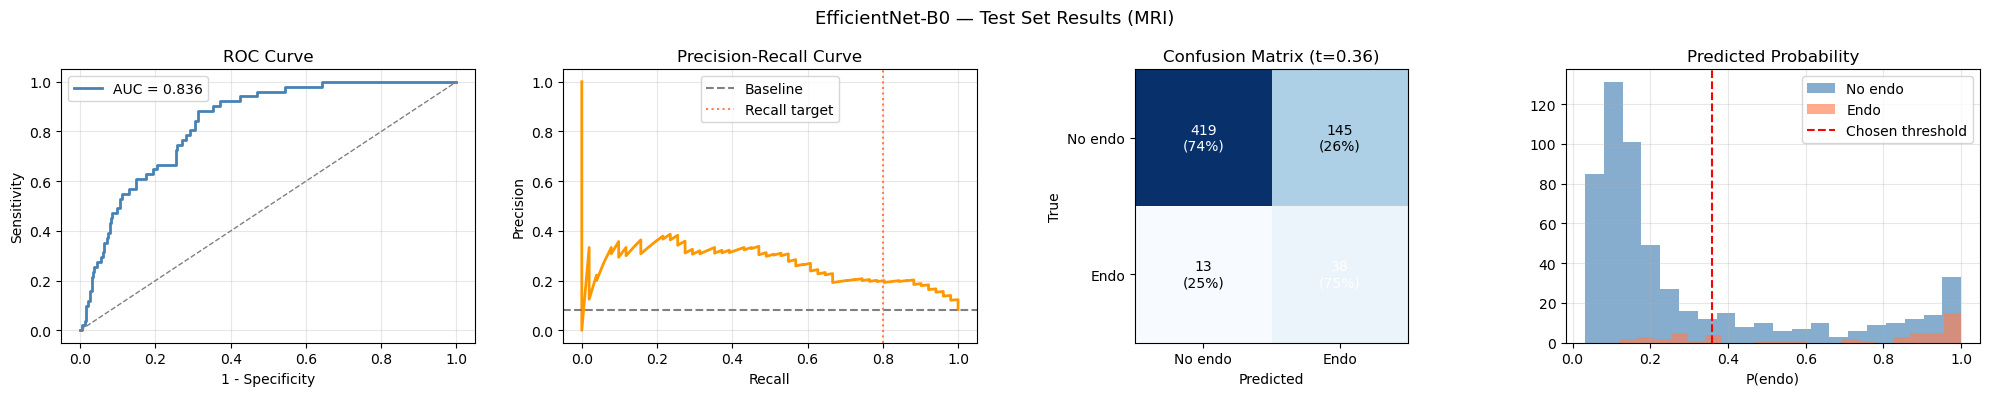

In [41]:
# ── 4.8 Evaluation plots — ROC, PR, confusion matrix, confidence ────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

fpr, tpr, roc_thresh = roc_curve(all_labels_test, all_probs)
axes[0].plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {test_auc:.3f}')
axes[0].plot([0,1],[0,1],'--',color='gray',linewidth=1)
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('1 - Specificity'); axes[0].set_ylabel('Sensitivity')
axes[0].legend(); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(all_labels_test, all_probs)
axes[1].plot(rec, prec, color='#FF9800', lw=2)
axes[1].axhline(all_labels_test.mean(), color='gray', linestyle='--', label='Baseline')
axes[1].axvline(SUCCESS_CRITERIA['Recall'], color='coral', linestyle=':', label='Recall target')
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(); axes[1].grid(alpha=0.3)

im = axes[2].imshow(cm, cmap='Blues')
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)', ha='center', va='center',
                     color='white' if cm_norm[i,j]>0.5 else 'black')
axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['No endo','Endo'])
axes[2].set_yticks([0,1]); axes[2].set_yticklabels(['No endo','Endo'])
axes[2].set_title(f'Confusion Matrix (t={CHOSEN_THRESHOLD:.2f})')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

pos_p = all_probs[all_labels_test==1]; neg_p = all_probs[all_labels_test==0]
axes[3].hist(neg_p, bins=20, alpha=0.65, label='No endo', color='steelblue')
axes[3].hist(pos_p, bins=20, alpha=0.65, label='Endo', color='coral')
axes[3].axvline(CHOSEN_THRESHOLD, color='red', linestyle='--', label='Chosen threshold')
axes[3].set_title('Predicted Probability'); axes[3].set_xlabel('P(endo)'); axes[3].legend(); axes[3].grid(alpha=0.3)

plt.suptitle('EfficientNet-B0 — Test Set Results (MRI)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mri_results.png', dpi=150, bbox_inches='tight')
plt.show()

**What this cell does:** Produces the standard visual diagnostics — ROC curve, precision-recall curve (with the recall target marked), confusion matrix at the chosen threshold, and the predicted-probability histogram split by true class with the chosen threshold drawn in. Look at the confidence histogram in particular: if positive and negative distributions overlap heavily, no threshold choice will fix that — it points back to needing more or better positive training data.

Sampled from 7 distinct patients across 2 institution(s)


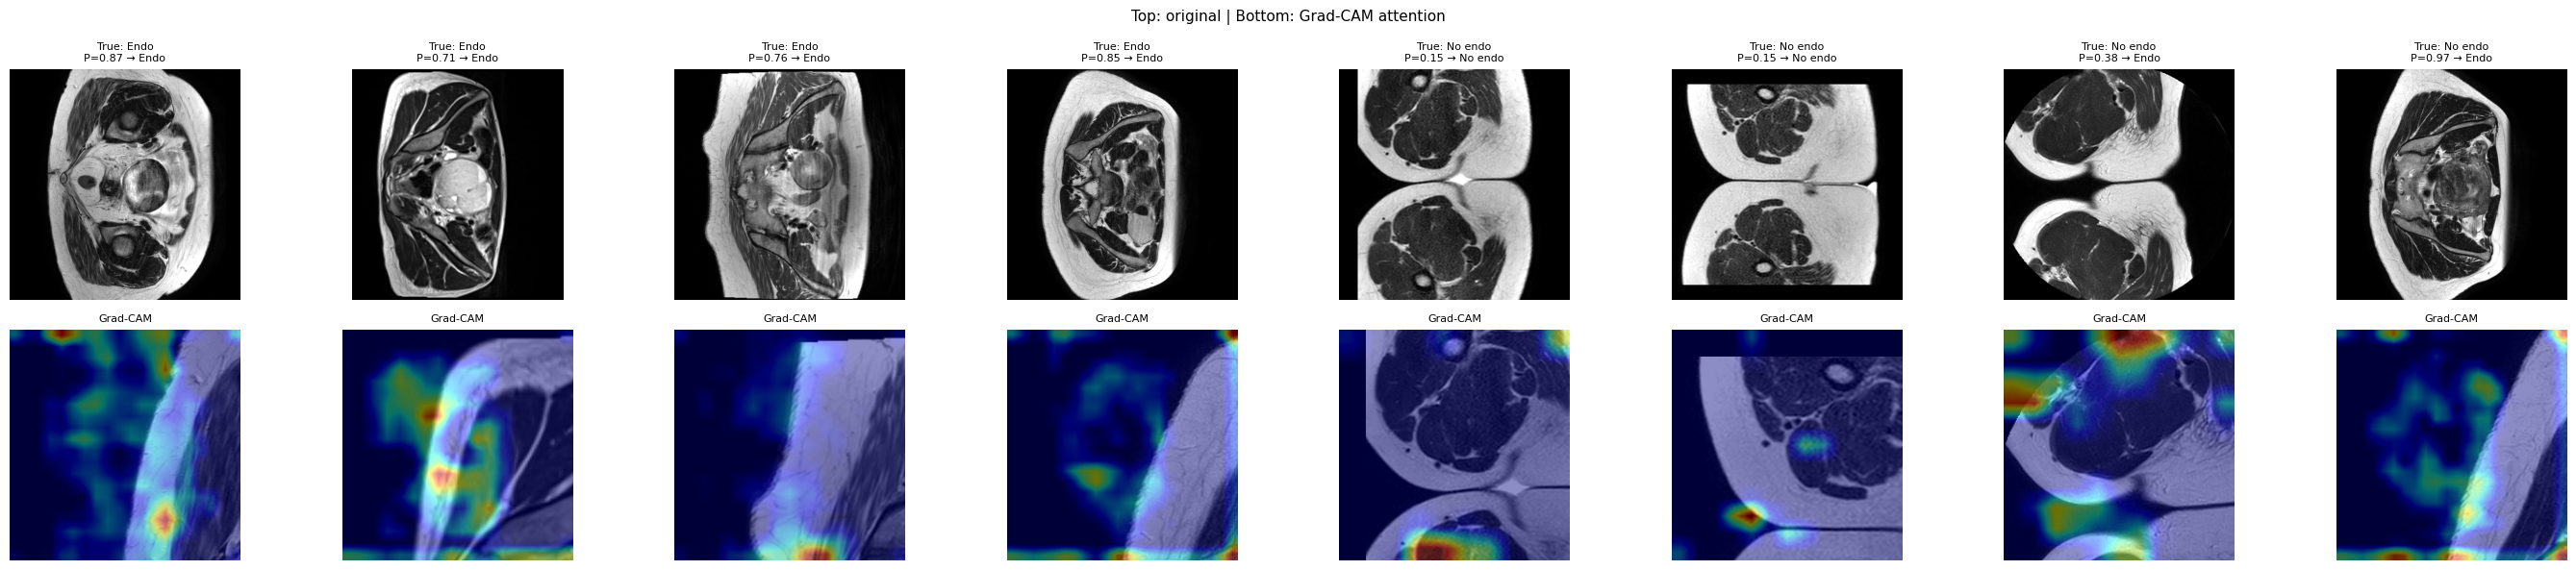

In [42]:
# ── 4.9 Grad-CAM ──────────────────────────────────────────────────
activations, gradients = {}, {}
def fwd_hook(module, inp, out): activations['feat'] = out.detach()
def bwd_hook(module, g_in, g_out): gradients['feat'] = g_out[0].detach()
target_layer = model.blocks[-1][-1]
h1 = target_layer.register_forward_hook(fwd_hook)
h2 = target_layer.register_full_backward_hook(bwd_hook)

def grad_cam(img_tensor):
    model.eval()
    img = img_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    out = model(img)
    model.zero_grad(); out.backward()
    grads, acts = gradients['feat'].squeeze(0), activations['feat'].squeeze(0)
    weights = grads.mean(dim=(1,2), keepdim=True)
    cam = (weights * acts).sum(dim=0).cpu().numpy()
    cam = np.maximum(cam, 0)
    if cam.max() > 0: cam /= cam.max()
    return np.array(Image.fromarray((cam*255).astype(np.uint8))
                     .resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)) / 255.0

def pick_diverse_slices(records_subset, n=4, seed=SEED):
    """
    One slice per DISTINCT patient, not consecutive slices from a single
    patient (which look nearly identical and aren't a fair qualitative
    check). For positive slices, prefers the one with the most lesion
    evidence per patient (using the v2 mask-derived voxel counts) so the
    example is actually diagnostic rather than a borderline/edge slice.
    Falls back to a middle slice (not slice 0, which is often at the edge
    of the scan's field of view) when voxel counts aren't available.
    """
    by_patient = defaultdict(list)
    for r in records_subset:
        by_patient[r['patient_id']].append(r)
    patient_ids = sorted(by_patient.keys())
    rng_local = random.Random(seed)
    rng_local.shuffle(patient_ids)   # diverse across institutions/patients, not list order

    chosen = []
    for pid in patient_ids:
        recs = by_patient[pid]
        if isinstance(recs[0].get('lesion_voxels'), dict):
            best = max(recs, key=lambda r: sum(r['lesion_voxels'].values()))
        else:
            best = recs[len(recs)//2]
        chosen.append(best)
        if len(chosen) >= n:
            break
    return chosen

pos_recs = pick_diverse_slices([r for r in test_records if r['label']==1], n=4)
neg_recs = pick_diverse_slices([r for r in test_records if r['label']==0], n=4)
samples = pos_recs + neg_recs
print(f"Sampled from {len(set(r['patient_id'] for r in samples))} distinct patients "
      f"across {len(set(r['institution'] for r in samples))} institution(s)")
fig, axes = plt.subplots(2, len(samples), figsize=(3.5*len(samples), 6))
for col, rec in enumerate(samples):
    fname = rec['filename']
    png_p = rec['dir'] / fname
    if not png_p.exists(): continue
    raw = np.array(Image.open(png_p).convert('L'), dtype=np.float32)
    sl = raw/255.0*2.0 - 1.0
    tens = torch.tensor(np.stack([sl,sl,sl],0), dtype=torch.float32)
    cam = grad_cam(tens)
    with torch.no_grad():
        prob = torch.sigmoid(model(tens.unsqueeze(0).to(DEVICE))).item()
    pred_label = 'Endo' if prob > CHOSEN_THRESHOLD else 'No endo'
    title = f'True: {"Endo" if rec["label"]==1 else "No endo"}\nP={prob:.2f} → {pred_label}'
    axes[0,col].imshow(raw/255., cmap='gray'); axes[0,col].set_title(title, fontsize=8); axes[0,col].axis('off')
    axes[1,col].imshow(raw/255., cmap='gray'); axes[1,col].imshow(cam, cmap='jet', alpha=0.45)
    axes[1,col].set_title('Grad-CAM', fontsize=8); axes[1,col].axis('off')
plt.suptitle('Top: original | Bottom: Grad-CAM attention', fontsize=11)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'gradcam.png', dpi=150, bbox_inches='tight')
plt.show()
h1.remove(); h2.remove()

**What this cell does:** Generates Grad-CAM attention maps for a diverse sample of test slices — one per distinct patient rather than the first N records in list order, since consecutive slices from a single patient look nearly identical and aren't a fair qualitative check. Positive examples prefer the slice with the most lesion evidence (from the v2 mask voxel counts), so you're looking at genuinely diagnostic slices, not edge-of-scan ones. **What to actually look for:** if attention consistently lands on image corners/borders rather than central anatomy — for either class — that's a shortcut-learning red flag, not a good sign, even if the numeric metrics look fine. Also worth checking whether any visible skin/reference markers in the scans correlate with the label across patients; if they do, the model may be keying off the marker rather than tissue. This matters specifically for this product: an explanation layer that describes attention on a scan artifact as if it were a real finding would actively mislead a patient, which is the opposite of this feature's purpose.

---
## Phase 5 — Calibration & Explanation Payload
Patient-level aggregation, probability calibration, and the finding-plus-Grad-CAM payload that gets
handed to the GenAI explanation layer — **not** an ESI score, and not an input to the fusion layer.

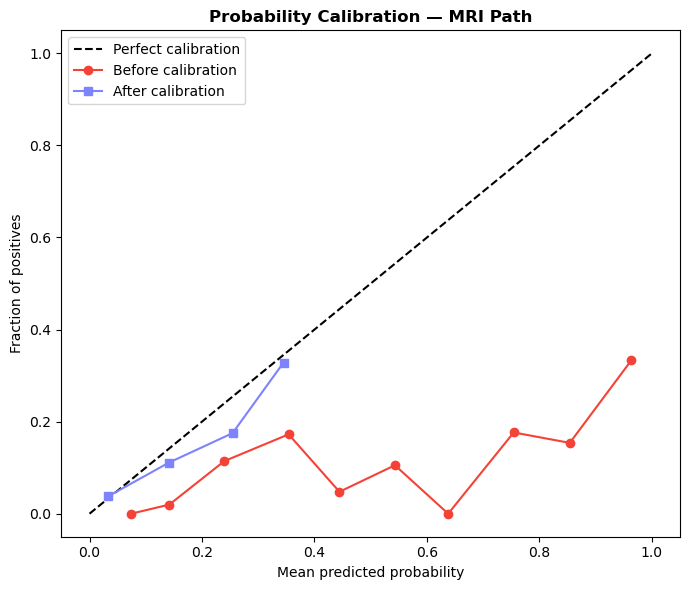

explain_mri_scan() defined ✓  (default aggregation='max' — favors recall)
Returns a finding + confidence + Grad-CAM pointer for the GenAI explanation layer —
NOT an esi_score/esi_tier, and NOT sent to the fusion layer.

Sample patient: D2-045  (39 slices)
{
  "finding": "No endometriosis indicators visible on this MRI slice",
  "finding_positive": false,
  "confidence": 0.333,
  "n_slices_reviewed": 39,
  "most_suspicious_slice": "outputs/mri_slices_v2/D2-045_sl018_label0.png",
  "aggregation": "max",
  "model_version": "endoscan_mri_efficientnet_b0_v1.0",
  "path": "mri_explainer",
  "role": "complementary_explainer",
  "disclaimer": "This is an AI-generated explanation of an existing scan, not a diagnosis. Always discuss results with your clinician."
}

This payload — plus the Grad-CAM image for 'most_suspicious_slice' from Phase 4.9 —
is what gets passed to the GenAI prompt, following the same pattern as the
laparoscopy notebook's get_gemini_explanation() / get_claude_explanation() 

In [43]:
# ── 5.1 Platt scaling — calibrate on val ────────────────────────────
# Calibration still matters here: a patient-facing explanation that says
# "the model is 90% confident" should mean roughly what it says.
platt = LogisticRegression(max_iter=1000)
platt.fit(val_probs_final.reshape(-1,1), val_labels_final)
cal_probs_test = platt.predict_proba(all_probs.reshape(-1,1))[:,1]

fig, ax = plt.subplots(figsize=(7,6))
fp_raw, mp_raw = calibration_curve(all_labels_test, all_probs, n_bins=10)
fp_cal, mp_cal = calibration_curve(all_labels_test, cal_probs_test, n_bins=10)
ax.plot([0,1],[0,1],'k--', label='Perfect calibration')
ax.plot(mp_raw, fp_raw, 'o-', color='#F44336', label='Before calibration')
ax.plot(mp_cal, fp_cal, 's-', color=ACCENT, label='After calibration')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction of positives')
ax.legend(); ax.set_title('Probability Calibration — MRI Path', fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'calibration.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5.2 Finding labels — plain-language, not a severity tier ────────
# This path reports what the scan shows, not how severe the condition is —
# severity/tiering already happened upstream via the structured/NLP path
# before this patient was diagnosed. Wording deliberately avoids anything
# that reads as a new diagnosis or a treatment recommendation.
FINDING_LABELS = {
    1: 'Possible endometriosis indicators visible on this MRI slice',
    0: 'No endometriosis indicators visible on this MRI slice',
}

# ── 5.3 Patient-level inference: build the explanation payload ──────
def explain_mri_scan(slice_paths: list, aggregation: str = 'max') -> dict:
    """
    Production inference for the MRI complementary-explainer path.

    This does NOT diagnose or tier the patient — it is only invoked for
    patients who already have a diagnosis (from the structured/NLP path or
    a clinician) and want their MRI explained in plain language. The
    returned dict is the payload for the GenAI explanation layer (same
    pattern as the laparoscopy notebook's Gemini cells) — it is never sent
    to the fusion layer.

    Args:
        slice_paths: list of PNG paths for ONE patient's MRI slices
        aggregation: 'max' (any suspicious slice flags the patient — higher
                      recall, recommended given recall is the primary metric)
                      or 'mean' (average across slices — smoother, lower recall)

    Returns:
        dict with the finding, confidence, per-slice detail for Grad-CAM
        generation, and a short structured summary the GenAI prompt can use.
    """
    model.eval()
    slice_probs = []
    for p in slice_paths:
        raw = np.array(Image.open(p).convert('L'), dtype=np.float32)
        sl = raw/255.0*2.0 - 1.0
        if sl.shape[0] != IMG_SIZE or sl.shape[1] != IMG_SIZE:
            sl = scipy_zoom(sl, (IMG_SIZE/sl.shape[0], IMG_SIZE/sl.shape[1]), order=1)
        tens = torch.tensor(np.stack([sl,sl,sl],0), dtype=torch.float32).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            raw_prob = torch.sigmoid(model(tens)).item()
        slice_probs.append(raw_prob)

    patient_raw_prob = max(slice_probs) if aggregation == 'max' else float(np.mean(slice_probs))
    cal_prob = platt.predict_proba([[patient_raw_prob]])[:,1][0]
    finding = int(cal_prob > CHOSEN_THRESHOLD)
    most_suspicious_idx = int(np.argmax(slice_probs))

    return {
        'finding':             FINDING_LABELS[finding],
        'finding_positive':    bool(finding),
        'confidence':          round(float(cal_prob), 4),
        'n_slices_reviewed':   len(slice_paths),
        'most_suspicious_slice': str(slice_paths[most_suspicious_idx]),
        'aggregation':         aggregation,
        'model_version':       'endoscan_mri_efficientnet_b0_v1.0',
        'path':                'mri_explainer',        # NOT 'mri_classifier' feeding a score
        'role':                'complementary_explainer',  # explicit — not diagnostic
        'disclaimer':          'This is an AI-generated explanation of an existing scan, '
                                'not a diagnosis. Always discuss results with your clinician.',
    }

print("explain_mri_scan() defined ✓  (default aggregation='max' — favors recall)")
print("Returns a finding + confidence + Grad-CAM pointer for the GenAI explanation layer —")
print("NOT an esi_score/esi_tier, and NOT sent to the fusion layer.")

# ── 5.4 Sample patient-level inference on a test patient ────────────
sample_patient_id = next(iter(test_ids))
sample_slice_paths = [
    r['dir'] / r['filename']
    for r in test_records if r['patient_id'] == sample_patient_id
]
result = explain_mri_scan(sample_slice_paths)
print(f"\nSample patient: {sample_patient_id}  ({len(sample_slice_paths)} slices)")
print(json.dumps(result, indent=2))
print("\nThis payload — plus the Grad-CAM image for 'most_suspicious_slice' from Phase 4.9 —")
print("is what gets passed to the GenAI prompt, following the same pattern as the")
print("laparoscopy notebook's get_gemini_explanation() / get_claude_explanation() cells.")

**What this cell does:** Calibrates raw model probabilities against true outcomes using Platt scaling fit on validation data (so a reported confidence of 70% actually means ~70% of such cases are positive — this matters for a patient-facing explanation that states a confidence number), then defines `explain_mri_scan()` — the production inference function that aggregates a *patient's* slice probabilities (via `max` by default, since that favours recall over averaging them out) and returns a **finding + confidence + pointer to the most suspicious slice for Grad-CAM**, explicitly labelled as the payload for the GenAI explanation layer. This is *not* an ESI score and is never sent to the fusion layer — it stops at 'here's what the scan shows and how confident the model is,' which is what a GenAI prompt (same pattern as the laparoscopy notebook's Gemini cells) turns into plain language for the patient. Ends with a sample inference on one real test patient so you can see the output shape end-to-end.

### 5.5 — GenAI Explanation Layer (Gemini)
Turns the finding + confidence + Grad-CAM into the plain-language explanation the patient actually sees.
Uses Gemini for now, matching the laparoscopy notebook — swap the provider later without changing
anything upstream, since this cell only consumes the `explain_mri_scan()` payload.

> **Before running:** set your key as an environment variable, never inline in the notebook —
> `export GEMINI_API_KEY="your-key-here"` in your shell before launching Jupyter. The laparoscopy
> notebook's key was pasted directly into cells 30b/30c and is now compromised — rotate that one in
> Google AI Studio if you haven't already, and don't repeat the pattern here.

In [44]:
# ── 5.5 GenAI explanation layer — Gemini ─────────────────────────────
!pip install google-generativeai opencv-python-headless -q

import os
import cv2
import google.generativeai as genai

GEMINI_API_KEY = os.environ.get("GEMINI_API_KEY")
assert GEMINI_API_KEY, (
    "GEMINI_API_KEY not found in the environment. Set it with "
    "`export GEMINI_API_KEY=...` in your shell before running this cell — "
    "never paste the key directly into a notebook cell."
)
genai.configure(api_key=GEMINI_API_KEY)

# Check https://ai.google.dev/gemini-api/docs/models for the current model
# name before running — Gemini model names change and old ones get retired.
GEMINI_MODEL_NAME = 'gemini-2.5-flash'
gemini_model = genai.GenerativeModel(GEMINI_MODEL_NAME)


def describe_attention_region(cam: np.ndarray, threshold: float = 0.6) -> str:
    """Crude region description from a Grad-CAM heatmap, for the prompt."""
    h, w = cam.shape
    ys, xs = np.where(cam > threshold)
    if len(ys) == 0:
        return "no single strongly localised region"
    cy, cx = ys.mean()/h, xs.mean()/w
    vert  = 'upper' if cy < 0.4 else ('lower' if cy > 0.6 else 'central')
    horiz = 'left'  if cx < 0.4 else ('right' if cx > 0.6 else 'central')
    return 'central' if (vert=='central' and horiz=='central') else f'{vert}-{horiz}'


def get_gemini_mri_explanation(patient_result: dict) -> str:
    """
    Send the most-suspicious-slice Grad-CAM overlay + finding to Gemini and
    get back a warm, plain-language explanation. The patient is ALREADY
    diagnosed — this explains what THIS SCAN shows, it does not diagnose.
    """
    slice_path = Path(patient_result['most_suspicious_slice'])
    raw = np.array(Image.open(slice_path).convert('L'), dtype=np.float32)
    sl  = raw/255.0*2.0 - 1.0
    tens = torch.tensor(np.stack([sl,sl,sl],0), dtype=torch.float32)
    cam  = grad_cam(tens)   # reuses grad_cam() defined in Phase 4.9

    region_desc = describe_attention_region(cam)
    cam_resized = cv2.resize(cam, (raw.shape[1], raw.shape[0]))
    heatmap = cv2.applyColorMap(np.uint8(255*cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    raw_rgb = np.stack([raw, raw, raw], axis=-1).astype(np.uint8)
    overlay = (0.55*raw_rgb + 0.45*heatmap).astype(np.uint8)
    overlay_img = Image.fromarray(overlay)

    prompt = f"""You are EndoScan AI, a compassionate assistant that helps patients
understand their own MRI scans. This patient has ALREADY been diagnosed —
your job is only to explain what THIS SPECIFIC SCAN shows, in plain language.
You are not making a new diagnosis and you are not assigning a severity level.

The image shown is an MRI slice with a Grad-CAM heatmap overlay. Red/yellow
areas show where the AI model focused its attention. Blue areas show regions
the model largely ignored.

Model findings for this scan:
- Finding    : {patient_result['finding']}
- Confidence : {patient_result['confidence']*100:.0f}%
- The model focused most on the {region_desc} area of the image

Write a warm, plain-English explanation of this scan for a patient with no
medical background. Rules:
- 3-4 short paragraphs, calm and reassuring tone
- Explain what the highlighted area means in simple terms
- Never use jargon without immediately explaining it
- Do not state or imply a new diagnosis or severity level — this only
  explains what this scan shows
- If this finding doesn't seem to match what their clinician told them,
  gently suggest they bring this explanation to their next appointment
- Always remind them this is an AI-generated explanation of an existing
  scan, not a diagnosis
- Encourage them to discuss it with their gynaecologist

Write only the explanation, nothing else."""

    response = gemini_model.generate_content([overlay_img, prompt])
    return response.text


# ── Run on the same sample patient from Phase 5.4 ────────────────────
explanation_text = get_gemini_mri_explanation(result)
print(f"Sample patient: {sample_patient_id}")
print(f"Finding: {result['finding']}  |  Confidence: {result['confidence']*100:.0f}%\n")
print(explanation_text)

AssertionError: GEMINI_API_KEY not found in the environment. Set it with `export GEMINI_API_KEY=...` in your shell before running this cell — never paste the key directly into a notebook cell.

**What this cell does:** Turns the finding + confidence from Phase 5.3 into the actual plain-language explanation a patient sees, using Gemini — same provider as your laparoscopy notebook, so you're not maintaining two different integrations while on a student budget. It reuses `grad_cam()` from Phase 4.9 to build a heatmap overlay for the patient's most suspicious slice, gives Gemini both the image and a text summary of the finding, and explicitly instructs it not to state or imply a new diagnosis — since the patient is already diagnosed and this is only explaining one scan. The key loads from an environment variable (`GEMINI_API_KEY`), never hardcoded — set it in your shell before running this cell. When you're ready to switch providers later, only this cell needs to change; everything upstream (`explain_mri_scan()`, the Grad-CAM logic) stays the same regardless of which GenAI provider turns it into text.

---
## Phase 6 — Deployment
Serialise the checkpoint and calibrator, and document the explanation-layer contract
(explicitly **not** a fusion-layer contract).

In [ ]:
import joblib

joblib.dump({'platt': platt, 'chosen_threshold': CHOSEN_THRESHOLD},
            RESULTS_DIR / 'mri_calibration.pkl')

model_meta = {
    'model_version':   'endoscan_mri_efficientnet_b0_v1.0',
    'model_type':      'EfficientNet-B0 + Platt calibration',
    'modality':        'MRI',
    'role':            'complementary_explainer',   # NOT diagnostic, NOT tiering
    'primary_metric':  'recall',
    'chosen_threshold': float(CHOSEN_THRESHOLD),
    'train_composition': {
        'real_slices':      len(train_records),
        'synthetic_slices': len(aug_for_train),
        'augment_positive_only': AUGMENT_POSITIVE_ONLY,
    },
    'test_metrics': {
        'recall':      round(float(sensitivity), 4),
        'specificity': round(float(specificity), 4),
        'auc':         round(float(test_auc), 4),
        'accuracy':    round(float(accuracy), 2),
    },
    'success_criteria': SUCCESS_CRITERIA,
    'aggregation_default': 'max',
    'output_contract': 'finding (str) + confidence (float) + Grad-CAM image, '
                        'for the GenAI explanation layer only',
    'used_by_fusion_layer': False,
    'eligible_patients': 'already diagnosed via structured/NLP path or a clinician, '
                          'requesting explanation of an existing MRI scan',
    'output_path': 'mri_explainer',
}
with open(RESULTS_DIR / 'mri_model_metadata.json', 'w') as f:
    json.dump(model_meta, f, indent=2)

torch.save({
    'model_state_dict': model.state_dict(),
    'history': history,
    'chosen_threshold': CHOSEN_THRESHOLD,
    'train_patients': list(train_ids), 'val_patients': list(val_ids), 'test_patients': list(test_ids),
    'metrics': {'recall': float(sensitivity), 'specificity': float(specificity), 'auc': float(test_auc)},
    'config': {'img_size': IMG_SIZE, 'batch_size': BATCH_SIZE, 'epochs_run': len(history['val_loss']),
               'best_epoch': best_ep, 'lr': LR, 'freeze_blocks': FREEZE_BLOCKS, 'dropout': DROPOUT,
               'modality': 'MRI', 'model': 'efficientnet_b0'}
}, CHECKPOINT_PATH)

print("Saved: mri_best_model.pt")
print("Saved: mri_calibration.pkl")
print("Saved: mri_model_metadata.json")
print()
print("=" * 55)
print("  ENDOSCAN MRI EXPLAINER — FINAL SUMMARY")
print("=" * 55)
print(f"  Role               : Complementary explainer (not diagnostic, not in fusion layer)")
print(f"  Model              : EfficientNet-B0 + Platt calibration")
print(f"  Train composition  : {len(train_records):,} real + {len(aug_for_train):,} synthetic")
print(f"  Checkpoint criterion: best val recall")
print(f"  Chosen threshold   : {CHOSEN_THRESHOLD:.2f} (tuned on val, not 0.5)")
print()
recall_status = '✓ PASS' if sensitivity >= SUCCESS_CRITERIA['Recall'] else '✗ FAIL'
print(f"  Test Recall (PRIMARY) : {sensitivity:.3f}  {recall_status}  (target ≥ {SUCCESS_CRITERIA['Recall']})")
print(f"  Test Specificity      : {specificity:.3f}  (target ≥ {SUCCESS_CRITERIA['Specificity']})")
print(f"  Test AUC              : {test_auc:.3f}  (informational, target ≥ {SUCCESS_CRITERIA['AUC']})")
print("=" * 55)

**What this cell does:** Saves everything needed to reproduce or deploy this model without retraining: the model checkpoint (weights + history + which patients were in each split), the Platt calibrator and chosen threshold, and a metadata JSON recording the train composition (real vs. synthetic counts), test metrics, and the success criteria they were checked against — with `role: complementary_explainer` and `used_by_fusion_layer: False` recorded explicitly, so nothing downstream mistakes this for a scoring path. Prints a final summary with the primary recall result and PASS/FAIL — this is the number to report back to your technical mentor.